In [1]:
import numpy as np, pandas as pd, scanpy as sc, anndata as ad, matplotlib.pyplot as plt, os, pickle
import celloracle as co, subprocess, matplotlib.colors as mcolors

# visualization settings required to see plots in jupyter notebook
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams["savefig.dpi"] = 300
# housekeeping settings to run the notebook
wd = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples'
out_path = os.path.join(wd, 'grn_CO')
os.makedirs(f"{out_path}/figures", exist_ok=True)
os.makedirs(f"{out_path}/out_files", exist_ok=True)
os.makedirs(f"{out_path}/scripts", exist_ok=True)
sc.settings.figdir = f"{out_path}/figures"

/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Loading base-GRN for ATAC; reading adata for RNA

In [26]:
input_objects_folder = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects'
path_to_adata = os.path.join(input_objects_folder, 'male_adata_stream_input.h5ad')
adata = sc.read_h5ad(path_to_adata)
n_cells_downsample = 30000 # Random downsampling into 30K cells if the anndata object include more than 30 K cells.
if adata.shape[0] > n_cells_downsample:
    print(f"Downsampling from {adata.shape[0]} to {n_cells_downsample} cells")
    sc.pp.subsample(adata, n_obs=n_cells_downsample, random_state=123) # Downsample into 30K cells

In [27]:
adata

AnnData object with n_obs × n_vars = 29904 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'dispersions', 'dispersions_norm', 'n_cells'
    uns: 'C_scANVI_colors', '_scvi_manager_uuid',

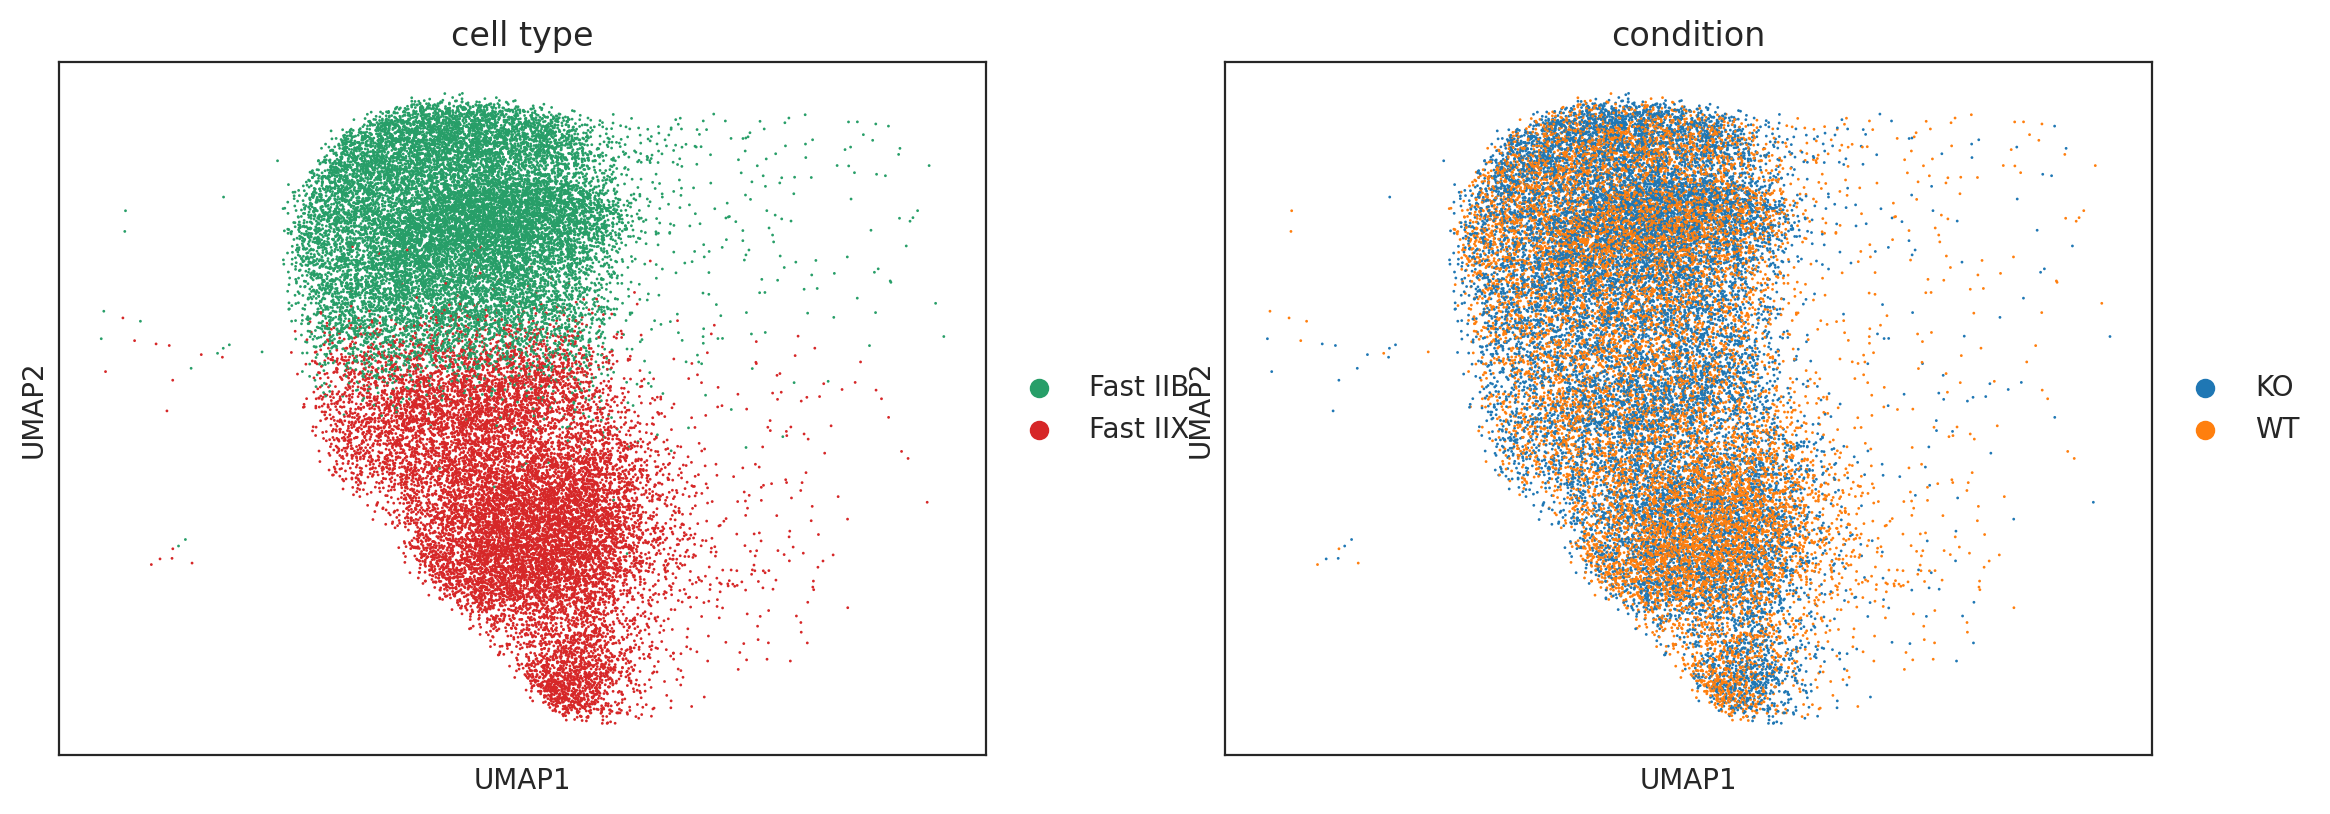

In [20]:
sc.pl.umap(adata, color=['C_scANVI', 'condition'], title=['cell type', 'condition'], ncols=2)

In [28]:
# CO uses the unscaled mRNA count for the Input of Oracle object.
# Get raw counts from .raw instead of layers["counts"]
if adata.raw is not None:
    # Convert raw to adata
    adata_raw = adata.raw.to_adata()
    
    # Subset raw to only the genes in current adata
    adata_raw = adata_raw[:, adata.var_names]
    
    # If raw.X is sparse, convert to dense array
    if hasattr(adata_raw.X, 'toarray'):
        adata.X = adata_raw.X.toarray().copy()
    else:
        adata.X = adata_raw.X.copy()
else:
    raise ValueError("No raw counts found in adata.raw")

In [29]:
print(adata.raw.X.max())

8.501502490191926


In [22]:
# Use only highly variable genes for the analysis
adata = adata[:, adata.var.highly_variable]

In [30]:
adata

AnnData object with n_obs × n_vars = 29904 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'dispersions', 'dispersions_norm', 'n_cells'
    uns: 'C_scANVI_colors', '_scvi_manager_uuid',

#### check base grn file format

In [8]:
base_GRN = co.data.load_mouse_scATAC_atlas_base_GRN()

Data not found in the local folder. Loading data from github. Data will be saved at /jet/home/asachan/celloracle_data/TFinfo_data


  0%|          | 0.00/9.01M [00:00<?, ?B/s]

In [9]:
display(base_GRN)

,peak_id,gene_short_name,9430076c15rik,Ac002126.6,Ac012531.1,Ac226150.2,Afp,Ahr,Ahrr,Aire,...,Znf784,Znf8,Znf816,Znf85,Zscan10,Zscan16,Zscan22,Zscan26,Zscan31,Zscan4
0,chr10_100050979_100052296,4930430F08Rik,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,chr10_101006922_101007748,SNORA17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,chr10_101144061_101145000,Mgat4c,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,chr10_10148873_10149183,9130014G24Rik,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,chr10_10149425_10149815,9130014G24Rik,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91971,chrX_99839037_99840900,Phka1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
91972,chrY_345823_347369,Eif2s3y,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
91973,chrY_581272_582790,Uty,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
91974,chrY_621772_623366,Ddx3y,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
oracle = co.Oracle()
# assigning scRNA (adata) to oracle object
oracle.import_anndata_as_raw_count(adata=adata, cluster_column_name="condition", embedding_name="X_umap")
# assigning scATAC (baseGRN) to oracle object
oracle.import_TF_data(TF_info_matrix=base_GRN)

In [ ]:
# CellOracle uses the same strategy as velocyto for visualizing cell transitions. 
# This process requires KNN imputation in advance.
# For the KNN imputation, we first need to calculate and select PCs. 

# Perform PCA
oracle.perform_PCA()
# Select important PCs
plt.plot(np.cumsum(oracle.pca.explained_variance_ratio_)[:100])
n_comps = np.where(np.diff(np.diff(np.cumsum(oracle.pca.explained_variance_ratio_))>0.002))[0][0]
plt.axvline(n_comps, c="k");plt.xlabel("Number of PCs");plt.ylabel("Explained variance");plt.title("PCA");plt.show()
print("Optimal numbers of PCA dimensions are found to be :",n_comps)
n_comps = min(n_comps, 50) # Ceiling the number of PCs to 50
# Performing KNN imputation
n_cell = oracle.adata.shape[0]
print(f"Number of cell in the data are :{n_cell}")
k = int(0.025*n_cell)
print(f"Auto-selected k is :{k}")
oracle.knn_imputation(n_pca_dims=n_comps, k=k, balanced=True, b_sight=k*8, b_maxl=k*4, n_jobs=-1)
# Save Oracle Object
oracle.to_hdf5(f'{out_path}/out_files/male_data.celloracle.oracle')

In [ ]:
def shell_script_header_cpu(save_path, job_name, n_cpu=24):
    sbatch_script_header_cpu = f"""#!/bin/bash
#SBATCH --job-name="{job_name}"
#SBATCH --output="{save_path}/scripts/{job_name}.log"
#SBATCH -p EM
#SBATCH --ntasks-per-node=1
#SBATCH --cpus-per-task={n_cpu}
#SBATCH -t 0-9:30:00

module load anaconda3/2022.10
source activate celloracle_env

"""
    return sbatch_script_header_cpu

oracle_links_fitting_py_script = f"""
import celloracle as co, pandas as pd, numpy as np, os
wd = '{wd}'
out_path = os.path.join(f'{{wd}}', 'out_data', 'grn_inference')
oracle = co.load_hdf5(f'{{out_path}}/out_files/male_data.celloracle.oracle')
links = oracle.get_links(cluster_name_for_GRN_unit="leiden", alpha=10, verbose_level=10)
links.filter_links(p=0.001, weight="coef_abs", threshold_number=2000)
links.get_network_score()
links.merged_score.to_csv(f'{{out_path}}/out_files/bayesian_fitted_1_merged_network_scores.csv')
# links.to_hdf5(f'{{out_path}}/out_files/bayesian_fitted_1.celloracle.links')
# Calculate GRN for each population in clustering unit.
links.filter_links() # Getting back to default thresholds (p<0.001 and top 10k) for simulation of GRN -- so that we have enough edges to simulate the GRN
oracle.get_cluster_specific_TFdict_from_Links(links_object=links) #### Runs another round on links.filtered_links to get final links
oracle.fit_GRN_for_simulation(alpha=10, use_cluster_specific_TFdict=True)

# Save the final links for the KO simulation
links_after_fit = co.Links(name="links_after_fit")
links_after_fit.filtered_links = links.filtered_links #### Just for initialization
for cluster in links.filtered_links.keys():
    cluster_specific_links = oracle.coef_matrix_per_cluster[cluster].stack().reset_index()
    cluster_specific_links.columns = ['source', 'target', 'coef_mean']
    cluster_specific_links = cluster_specific_links[cluster_specific_links ['coef_mean'] != 0].reset_index(drop=True)
    cluster_specific_links['coef_abs'] = np.abs(cluster_specific_links['coef_mean'])
    cluster_specific_links.to_csv(f'{{out_path}}/out_files/cluster_{{cluster}}.csv', index=False)
    links_after_fit.filtered_links[cluster] = cluster_specific_links
links_after_fit.get_network_score()
links_after_fit.merged_score.to_csv(f'{{out_path}}/out_files/ridge_fitted_2_merged_network_scores.csv')
# Saving for KO simulation.
oracle.to_hdf5(f'{{out_path}}/out_files/oracle_fitted.celloracle.oracle')
"""

job_name = 'oracle_links_fitting'
# Create python script
with open(f'{out_path}/scripts/{job_name}.py', "w", encoding="utf-8") as f:
    f.write(oracle_links_fitting_py_script)
# Create bash script
with open(f'{out_path}/scripts/{job_name}.sh', "w", encoding="utf-8") as f:
    f.write(shell_script_header_cpu(save_path = out_path, job_name = job_name))
    f.write(f"python {out_path}/scripts/oracle_links_fitting.py \n")
    f.write(f"echo 'Oracle links fitting completed' \n")

subprocess.run(["sbatch", f'{out_path}/scripts/{job_name}.sh'])
print(f"Submitted {job_name}.sh")